<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Air-Quality-_PM-2.5/XAI_Tra_without_iteration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# SHAP XAI for Random Forest
# PM2.5 Prediction
# =========================

!pip install shap -q

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================
# 1. Load datasets
# =========================

train_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/PM 2.5/pm25_training_dataset.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/PM 2.5/pm25_testing_dataset.csv")

# =========================
# 2. Define features and target
# =========================

features = [
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "humidity",
    "cloud",
    "visibility_km",
    "longitude",
    "temperature_celsius",
    "condition_text",
    "uv_index",
    "wind_mph",
    "precip_mm",
    "gust_mph",
    "wind_degree"
]

target = "air_quality_PM2.5"

# =========================
# 3. Keep required columns
# =========================

train_df = train_df[features + [target]].copy()
test_df = test_df[features + [target]].copy()

# Convert all columns to numeric
for col in features + [target]:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce")

# Remove missing values
train_df = train_df.dropna()
test_df = test_df.dropna()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# =========================
# 4. Evaluation function
# =========================

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true_safe = np.where(np.array(y_true) == 0, 1e-10, y_true)
    accuracy = 100 - (np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100)

    return mse, rmse, mae, r2, accuracy

# =========================
# 5. Train Random Forest model
# =========================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# =========================
# 6. Predict and evaluate
# =========================

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

train_metrics_rf = evaluate_model(y_train, y_train_pred_rf)
test_metrics_rf = evaluate_model(y_test, y_test_pred_rf)

print("Random Forest - Training Results")
print("MSE:", train_metrics_rf[0])
print("RMSE:", train_metrics_rf[1])
print("MAE:", train_metrics_rf[2])
print("R2:", train_metrics_rf[3])
print("Accuracy (%):", train_metrics_rf[4])

print("\nRandom Forest - Testing Results")
print("MSE:", test_metrics_rf[0])
print("RMSE:", test_metrics_rf[1])
print("MAE:", test_metrics_rf[2])
print("R2:", test_metrics_rf[3])
print("Accuracy (%):", test_metrics_rf[4])



Random Forest - Training Results
MSE: 6.74553534625936
RMSE: 2.597216846214301
MAE: 1.164703545124132
R2: 0.9957650800571191
Accuracy (%): 94.57193384194395

Random Forest - Testing Results
MSE: 52.462456544860274
RMSE: 7.243097165222919
MAE: 3.3430925322103
R2: 0.9123731501627438
Accuracy (%): 85.51587537952456


In [2]:
rf_model
X_test
y_test
features

['air_quality_PM10',
 'air_quality_Carbon_Monoxide',
 'air_quality_Nitrogen_dioxide',
 'air_quality_Sulphur_dioxide',
 'humidity',
 'cloud',
 'visibility_km',
 'longitude',
 'temperature_celsius',
 'condition_text',
 'uv_index',
 'wind_mph',
 'precip_mm',
 'gust_mph',
 'wind_degree']

In [3]:
print(X_test.shape)
print(type(rf_model))

(26001, 15)
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [4]:
import shap
import numpy as np
import pandas as pd

print("Starting SHAP...")

X_shap = X_test.sample(n=50, random_state=42)
print("Sample created:", X_shap.shape)

explainer = shap.TreeExplainer(rf_model)
print("Explainer created")

shap_values = explainer.shap_values(X_shap)
print("SHAP calculated:", np.array(shap_values).shape)

Starting SHAP...
Sample created: (50, 15)
Explainer created
SHAP calculated: (50, 15)


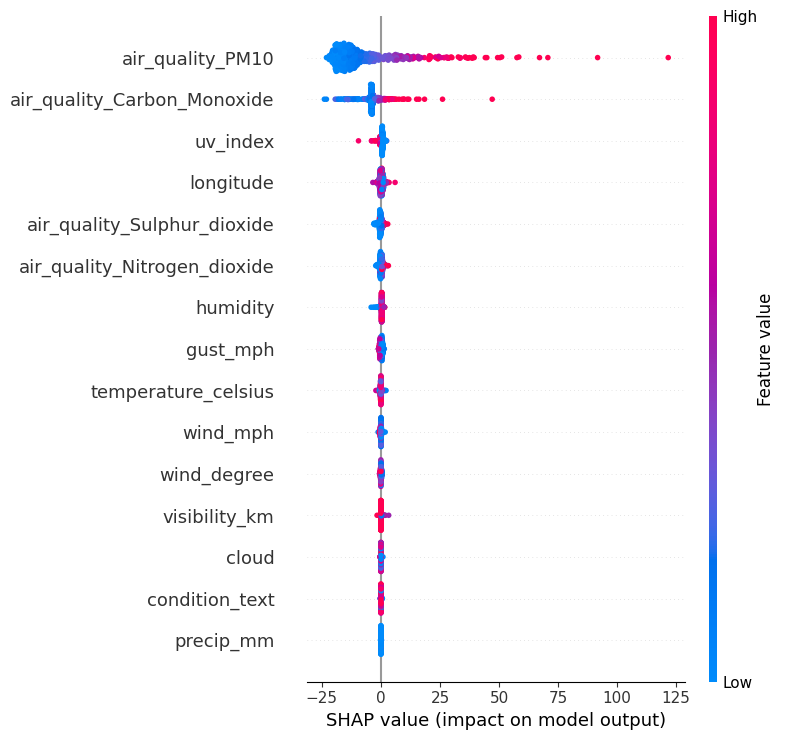

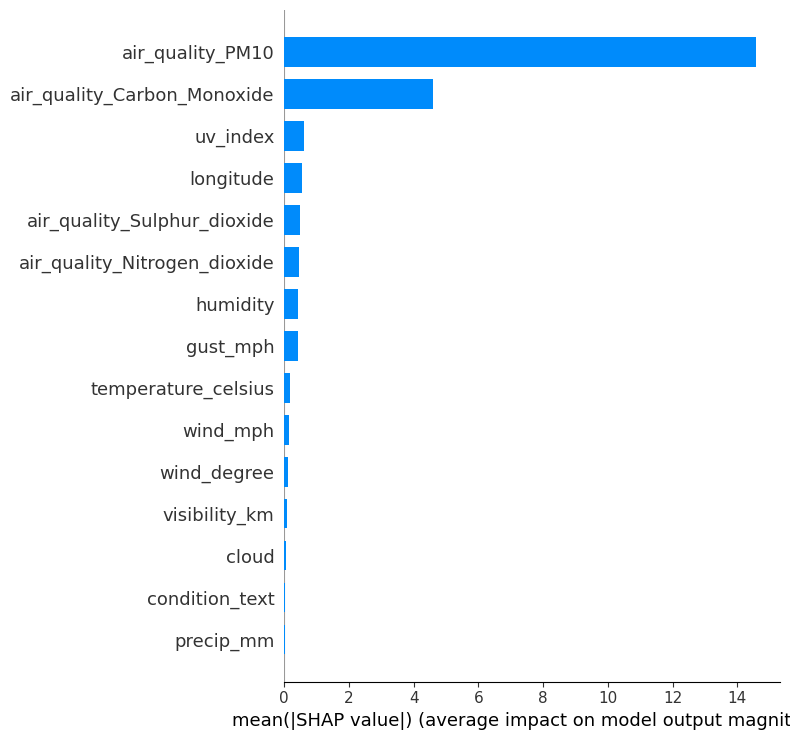


SHAP Feature Importance Table


,Feature,Mean Absolute SHAP Value
0,air_quality_PM10,14.586536
1,air_quality_Carbon_Monoxide,4.599663
10,uv_index,0.606115
7,longitude,0.553689
3,air_quality_Sulphur_dioxide,0.490052
2,air_quality_Nitrogen_dioxide,0.445189
4,humidity,0.424577
13,gust_mph,0.411663
8,temperature_celsius,0.169666
11,wind_mph,0.140325


Actual PM2.5 value: 6.55
Predicted PM2.5 value: 6.716109999999999


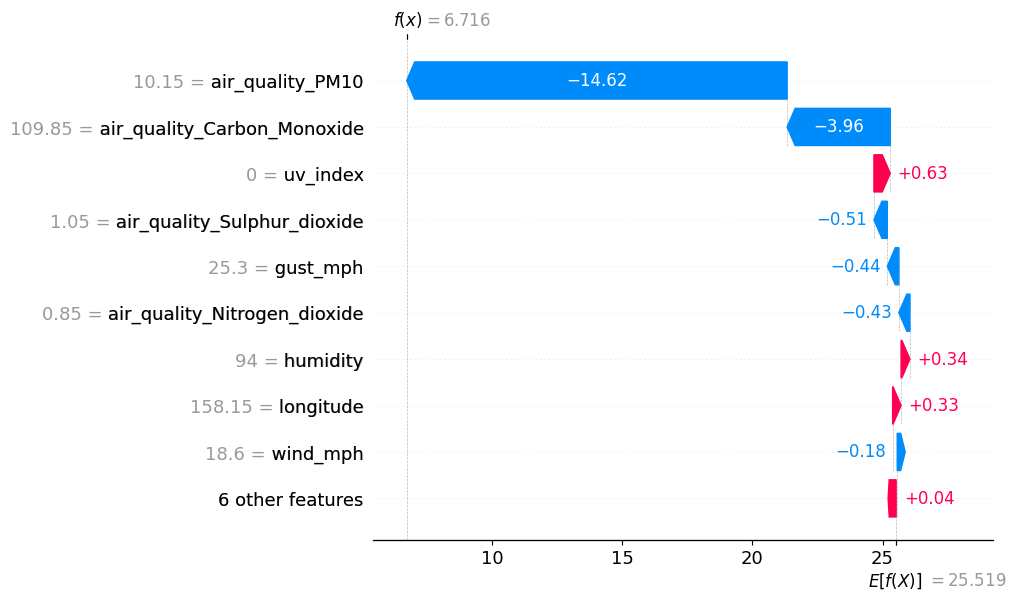

In [5]:
# =========================
# 7. SHAP Explainable AI
# =========================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use smaller sample first
X_shap = X_test.sample(n=500, random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

# =========================
# 8. SHAP Summary Plot
# =========================

shap.summary_plot(shap_values, X_shap)

# =========================
# 9. SHAP Bar Plot
# =========================

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

# =========================
# 10. SHAP Feature Importance Table
# =========================

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean Absolute SHAP Value": np.abs(shap_values).mean(axis=0)
}).sort_values(by="Mean Absolute SHAP Value", ascending=False)

print("\nSHAP Feature Importance Table")
display(shap_importance)

# =========================
# 11. Explain One Prediction - safer waterfall plot
# =========================

sample_index = 0

prediction = rf_model.predict(X_shap.iloc[[sample_index]])[0]
actual = y_test.loc[X_shap.index[sample_index]]

print("Actual PM2.5 value:", actual)
print("Predicted PM2.5 value:", prediction)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_shap.iloc[sample_index],
        feature_names=X_shap.columns
    )
)